**Topic**: Linear Regression and Gradient Descent  
**Objective**:  
- Understand the linear regression model  
- Visualize how Gradient Descent updates model parameters  
- Gain intuition about loss minimization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from sklearn.linear_model import LinearRegression
plt.style.use('fivethirtyeight')

def figure1(x_train, y_train, x_val, y_val):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].scatter(x_train, y_train)
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y')
    ax[0].set_ylim([0, 3.1])
    ax[0].set_title('Generated Data - Train')

    ax[1].scatter(x_val, y_val, c='r')
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y')
    ax[1].set_ylim([0, 3.1])
    ax[1].set_title('Generated Data - Validation')
    fig.tight_layout()

    return fig, ax

def figure2(x_train, y_train, b, w, color='k'):
    # Generates evenly spaced x feature
    x_range = np.linspace(0, 1, 101)
    # Computes yhat
    yhat_range = b + w * x_range

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_ylim([0, 3])

    # Dataset
    ax.scatter(x_train, y_train)
    # Predictions
    ax.plot(x_range, yhat_range, label='Model\'s predictions', c=color, linestyle='--')

    # Annotations
    ax.annotate('b = {:.4f} w = {:.4f}'.format(b[0], w[0]), xy=(.2, .55), c=color)
    ax.legend(loc=0)
    fig.tight_layout()
    return fig, ax

def figure3(x_train, y_train, b, w):
    fig, ax = figure2(x_train, y_train, b, w)

    # First data point
    x0, y0 = x_train[0][0], y_train[0][0]
    # First data point
    ax.scatter([x0], [y0], c='r')
    # Vertical line showing error between point and prediction
    ax.plot([x0, x0], [b[0] + w[0] * x0, y0 - .03], c='r', linewidth=2, linestyle='--')
    ax.arrow(x0, y0 - .03, 0, .03, color='r', shape='full', lw=0, length_includes_head=True, head_width=.03)
    ax.arrow(x0, b[0] + w[0] * x0 + .05, 0, -.03, color='r', shape='full', lw=0, length_includes_head=True, head_width=.03)
    # Annotations
    ax.annotate(r'$error_0$', xy=(.8, 1.5))

    fig.tight_layout()
    return fig, ax

def fit_model(x_train, y_train):
    # Fits a linear regression to find the actual b and w that minimize the loss
    regression = LinearRegression()
    regression.fit(x_train, y_train)
    b_minimum, w_minimum = regression.intercept_[0], regression.coef_[0][0]
    return b_minimum, w_minimum

def find_index(b, w, bs, ws):
    # Looks for the closer indexes for the updated b and w inside their respective ranges
    b_idx = np.argmin(np.abs(bs[0, :] - b))
    w_idx = np.argmin(np.abs(ws[:, 0] - w))

    # Closest values for b and w
    fixedb, fixedw = bs[0, b_idx], ws[w_idx, 0]

    return b_idx, w_idx, fixedb, fixedw


def figure4(x_train, y_train, b, w, bs, ws, all_losses):
    b_minimum, w_minimum = fit_model(x_train, y_train)


    figure = plt.figure(figsize=(12, 6))

    # 1st plot
    ax1 = figure.add_subplot(1, 2, 1, projection='3d')
    ax1.set_xlabel('b')
    ax1.set_ylabel('w')
    ax1.set_title('Loss Surface')

    surf = ax1.plot_surface(bs, ws, all_losses, rstride=1, cstride=1, alpha=.5, cmap=plt.cm.jet, linewidth=0, antialiased=True)
    ax1.contour(bs[0, :], ws[:, 0], all_losses, 10, offset=-1, cmap=plt.cm.jet)


    bidx, widx, _, _ = find_index(b_minimum, w_minimum, bs, ws)
    ax1.scatter(b_minimum, w_minimum, all_losses[bidx, widx], c='k')
    ax1.text(-.3, 2.5, all_losses[bidx, widx], 'Minimum', zdir=(1, 0, 0))
    # Random start
    bidx, widx, _, _ = find_index(b, w, bs, ws)
    ax1.scatter(b, w, all_losses[bidx, widx], c='k')
    # Annotations
    ax1.text(-.2, -1.5, all_losses[bidx, widx], 'Random\n Start', zdir=(1, 0, 0))

    ax1.view_init(40, 260)

    # 2nd plot
    ax2 = figure.add_subplot(1, 2, 2)
    ax2.set_xlabel('b')
    ax2.set_ylabel('w')
    ax2.set_title('Loss Surface')

    # Loss surface
    CS = ax2.contour(bs[0, :], ws[:, 0], all_losses, cmap=plt.cm.jet)
    ax2.clabel(CS, inline=1, fontsize=10)
    # Minimum
    ax2.scatter(b_minimum, w_minimum, c='k')
    # Random start
    ax2.scatter(b, w, c='k')
    # Annotations
    ax2.annotate('Random Start', xy=(-.2, 0.05), c='k')
    ax2.annotate('Minimum', xy=(.5, 2.2), c='k')

    figure.tight_layout()
    return figure, (ax1, ax2)

def figure5(x_train, y_train, b, w, bs, ws, all_losses):
    b_minimum, w_minimum = fit_model(x_train, y_train)

    b_idx, w_idx, fixedb, fixedw = find_index(b, w, bs, ws)

    b_range = bs[0, :]
    w_range = ws[:, 0]

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].set_title('Loss Surface')
    axs[0].set_xlabel('b')
    axs[0].set_ylabel('w')
    # Loss surface
    CS = axs[0].contour(bs[0, :], ws[:, 0], all_losses, cmap=plt.cm.jet)
    axs[0].clabel(CS, inline=1, fontsize=10)
    # Minimum
    axs[0].scatter(b_minimum, w_minimum, c='k')
    # Starting point
    axs[0].scatter(fixedb, fixedw, c='k')
    # Vertical section
    axs[0].plot([fixedb, fixedb], w_range[[0, -1]], linestyle='--', c='r', linewidth=2)
    # Annotations
    axs[0].annotate('Minimum', xy=(.5, 2.2), c='k')
    axs[0].annotate('Random Start', xy=(fixedb + .1, fixedw + .1), c='k')

    axs[1].set_ylim([-.1, 15.1])
    axs[1].set_xlabel('w')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Fixed: b = {:.2f}'.format(fixedb))
    # Loss
    axs[1].plot(w_range, all_losses[:, b_idx], c='r', linestyle='--', linewidth=2)
    # Starting point
    axs[1].plot([fixedw], [all_losses[w_idx, b_idx]], 'or')

    fig.tight_layout()
    return fig, axs

def figure6(x_train, y_train, b, w, bs, ws, all_losses):
    b_minimum, w_minimum = fit_model(x_train, y_train)

    b_idx, w_idx, fixedb, fixedw = find_index(b, w, bs, ws)

    b_range = bs[0, :]
    w_range = ws[:, 0]

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].set_title('Loss Surface')
    axs[0].set_xlabel('b')
    axs[0].set_ylabel('w')
    # Loss surface
    CS = axs[0].contour(bs[0, :], ws[:, 0], all_losses, cmap=plt.cm.jet)
    axs[0].clabel(CS, inline=1, fontsize=10)
    # Minimum
    axs[0].scatter(b_minimum, w_minimum, c='k')
    # Starting point
    axs[0].scatter(fixedb, fixedw, c='k')
    # Horizontal section
    axs[0].plot(b_range[[0, -1]], [fixedw, fixedw], linestyle='--', c='k', linewidth=2)
    # Annotations
    axs[0].annotate('Minimum', xy=(.5, 2.2), c='k')
    axs[0].annotate('Random Start', xy=(fixedb + .1, fixedw + .1), c='k')

    axs[1].set_ylim([-.1, 15.1])
    axs[1].set_xlabel('b')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Fixed: w = {:.2f}'.format(fixedw))
    # Loss
    axs[1].plot(b_range, all_losses[w_idx, :], c='k', linestyle='--', linewidth=2)
    # Starting point
    axs[1].plot([fixedb], [all_losses[w_idx, b_idx]], 'ok')

    fig.tight_layout()
    return fig, axs

def figure7(b, w, bs, ws, all_losses):
    b_range = bs[0, :]
    w_range = ws[:, 0]

    b_idx, w_idx, fixedb, fixedw = find_index(b, w, bs, ws)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].set_ylim([-.1, 6.1])
    axs[0].set_xlabel('w')
    axs[0].set_ylabel('MSE (loss)')
    axs[0].set_title('Fixed: b = {:.2f}'.format(fixedb))
    # Red rectangle
    rect = Rectangle((-.3, 2.3),.5, .5)
    pc = PatchCollection([rect], facecolor='r', alpha=.3, edgecolor='r')
    axs[0].add_collection(pc)
    # Loss - fixed b
    axs[0].plot(w_range, all_losses[:, b_idx], c='r', linestyle='--', linewidth=2)
    # Starting point
    axs[0].plot([fixedw], [all_losses[w_idx, b_idx]], 'or')

    axs[1].set_ylim([-.1, 6.1])
    axs[1].set_xlabel('b')
    axs[1].set_ylabel('MSE (loss)')
    axs[1].set_title('Fixed: w = {:.2f}'.format(fixedw))
    axs[1].label_outer()
    # Black rectangle
    rect = Rectangle((.3, 2.3), .5, .5)
    pc = PatchCollection([rect], facecolor='k', alpha=.3, edgecolor='k')
    axs[1].add_collection(pc)
    # Loss - fixed w
    axs[1].plot(b_range, all_losses[w_idx, :], c='k', linestyle='--', linewidth=2)
    # Starting point
    axs[1].plot([fixedb], [all_losses[w_idx, b_idx]], 'ok')

    fig.tight_layout()
    return fig, axs


def loss_curves(b_idx, w_idx, b_idx_after, w_idx_after, all_losses):
    # BEFORE
    # Loss curve for b, given w is fixed
    loss_fixedw = all_losses[w_idx, :]
    # Loss curve for w, given b is fixed
    loss_fixedb = all_losses[:, b_idx]
    # Loss before
    loss_before = all_losses[w_idx, b_idx]

    # AFTER
    # Loss after w is updated
    loss_after_w = all_losses[w_idx_after, b_idx]
    # Loss after b is updated
    loss_after_b = all_losses[w_idx, b_idx_after]
    return loss_fixedb, loss_fixedw, loss_before, loss_after_b, loss_after_w


def calc_gradient(parm_before, parm_after, loss_before, loss_after):
    # Computes changes in parm and loss
    delta_parm = parm_after - parm_before
    delta_loss = loss_after - loss_before
    # Computes gradient for parm
    manual_grad = delta_loss / delta_parm
    return manual_grad, delta_parm, delta_loss


def figure8(b, w, bs, ws, all_losses):
    b_range = bs[0, :]
    w_range = ws[:, 0]

    # BEFORE
    b_idx, w_idx, bs_before, ws_before = find_index(b, w, bs, ws)
    # AFTER
    b_idx_after, w_idx_after, bs_after, ws_after = find_index(b + .12, w + .12, bs, ws)

    loss_fixedb, loss_fixedw, loss_before, loss_after_b, loss_after_w = loss_curves(b_idx, w_idx, b_idx_after, w_idx_after, all_losses)

    # Computes gradient for b
    manual_grad_b, delta_b, delta_mse_b = calc_gradient(bs_before, bs_after, loss_before, loss_after_b)
    # Computes gradient for w
    manual_grad_w, delta_w, delta_mse_w = calc_gradient(ws_before, ws_after, loss_before, loss_after_w)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].set_ylim([2.3, 2.8])
    axs[0].set_xlim([-.3, .2])
    axs[0].set_xlabel('w')
    axs[0].set_ylabel('MSE (loss)')
    axs[0].set_title('Fixed: b = {:.2f}'.format(bs_before))
    # Loss curve
    axs[0].plot(w_range, loss_fixedb, c='r', linestyle='--', linewidth=2)
    # Point - before
    axs[0].plot([ws_before], [loss_before], 'or')
    # Point - after
    axs[0].plot([ws_after], [loss_after_w], 'or')

    # Arrows
    axs[0].arrow(ws_after, loss_before, .01, 0, color='r', shape='full', lw=0, length_includes_head=True, head_width=.01)
    axs[0].arrow(ws_before, loss_after_w, 0, -0.01, color='r', shape='full', lw=0, length_includes_head=True, head_width=.01)
    axs[0].plot([ws_before, ws_after], [loss_before, loss_before], 'r-', linewidth=1.5)
    axs[0].plot([ws_before, ws_before], [loss_after_w, loss_before], 'r-', linewidth=1.5)

    # Annotations
    axs[0].annotate(r'$\delta w = {:.2f}$'.format(delta_w), xy=(.0, 2.7), c='k', fontsize=15)
    axs[0].annotate(r'$\delta MSE = {:.2f}$'.format(delta_mse_w), xy=(-.23, 2.45), c='k', fontsize=15)
    axs[0].annotate(r'$\frac{\delta MSE}{\delta w} \approx' + '{:.2f}$'.format(manual_grad_w), xy=(-.05, 2.6), c='k', fontsize=17)

    axs[1].set_ylim([2.3, 2.8])
    axs[1].set_xlim([.3, .8])
    axs[1].set_xlabel('b')
    axs[1].set_ylabel('MSE (loss)')
    axs[1].set_title('Fixed: w = {:.2f}'.format(ws_before))
    # Loss Curve
    axs[1].plot(b_range, loss_fixedw, c='k', linestyle='--', linewidth=2)
    # Point - before
    axs[1].plot([bs_before], [loss_before], 'ok')
    # Point - after
    axs[1].plot([bs_after], [loss_after_b], 'ok')

    # Arrows
    axs[1].arrow(bs_after, loss_before, .01, 0, color='k', shape='full', lw=0, length_includes_head=True, head_width=.01)
    axs[1].arrow(bs_before, loss_after_b, 0, -0.01, color='k', shape='full', lw=0, length_includes_head=True, head_width=.01)
    axs[1].plot([bs_before, bs_after], [loss_before, loss_before], 'k-', linewidth=1.5)
    axs[1].plot([bs_before, bs_before], [loss_after_b, loss_before], 'k-', linewidth=1.5)

    # Annotations
    axs[1].annotate(r'$\delta b = {:.2f}$'.format(delta_b), xy=(.67, 2.7), c='k', fontsize=15)
    axs[1].annotate(r'$\delta MSE = {:.2f}$'.format(delta_mse_b), xy=(.45, 2.32), c='k', fontsize=15)
    axs[1].annotate(r'$\frac{\delta MSE}{\delta b} \approx' + '{:.2f}$'.format(manual_grad_b), xy=(.62, 2.6), c='k', fontsize=17)

    axs[1].label_outer()

    fig.tight_layout()
    return fig, axs


def figure9(x_train, y_train, b, w):
    # Since we updated b and w, let's regenerate the initial ones
    # That's how using a random seed is useful, for instance
    np.random.seed(42)
    b_initial = np.random.randn(1)
    w_initial = np.random.randn(1)

    fig, ax = figure2(x_train, y_train, b_initial, w_initial)

    # Generates evenly spaced x feature
    x_range = np.linspace(0, 1, 101)
    # Model's predictions for updated paramaters
    yhat_range = b + w * x_range
    # Updated predictions
    ax.plot(x_range, yhat_range, label='Using parameters\nafter one update', c='g', linestyle='--')
    # Annotations
    ax.annotate('b = {:.4f} w = {:.4f}'.format(b[0], w[0]), xy=(.2, .95), c='g')

    fig.tight_layout()
    return fig, ax


def figure10(b, w, bs, ws, all_losses, manual_grad_b, manual_grad_w, lr):
    b_range = bs[0, :]
    w_range = ws[:, 0]

    # BEFORE
    b_idx, w_idx, bs_before, ws_before = find_index(b, w, bs, ws)
    # AFTER
    new_b_idx, new_w_idx, bs_after, ws_after = find_index(bs_before - lr * manual_grad_b,
                                                          ws_before - lr * manual_grad_w,
                                                          bs,
                                                          ws)
    # Loss before
    loss_before = all_losses[w_idx, b_idx]
    loss_fixedb = all_losses[:, b_idx]
    loss_fixedw = all_losses[w_idx, :]
    loss_after_b = all_losses[w_idx, new_b_idx]
    loss_after_w = all_losses[new_w_idx, b_idx]

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].set_ylim([-.1, 6.1])
    axs[0].set_xlabel('w')
    axs[0].set_ylabel('MSE (loss)')
    axs[0].set_title('Fixed: b = {:.2f}'.format(bs_before))

    # Loss curve for w, given fixed b
    axs[0].plot(w_range, loss_fixedb, c='r', linestyle='--', linewidth=2)
    # w before update
    axs[0].plot([ws_before], [loss_before], 'or')

    # Arrows
    axs[0].arrow(ws_after, loss_before, .1, 0, color='r', shape='full', lw=0, length_includes_head=True, head_width=.1)
    axs[0].plot([ws_before, ws_after], [loss_before, loss_before], 'r-', linewidth=1.5)
    axs[0].plot([ws_after], [loss_after_w], 'or')

    # Annotations
    axs[0].annotate(r'$\eta = {:.2f}$'.format(lr), xy=(1.6, 5.5), c='k', fontsize=17)
    axs[0].annotate(r'$-\eta \frac{\delta MSE}{\delta b} \approx' + '{:.2f}$'.format(-lr * manual_grad_w), xy=(1, 2), c='k', fontsize=17)

    axs[1].set_ylim([-.1, 6.1])
    axs[1].set_xlabel('b')
    axs[1].set_ylabel('MSE (loss)')
    axs[1].set_title('Fixed: w = {:.2f}'.format(ws_before))
    axs[1].label_outer()

    # Loss curve for b, given fixed w
    axs[1].plot(b_range, loss_fixedw, c='k', linestyle='--', linewidth=2)
    # b before update
    axs[1].plot([bs_before], [loss_before], 'ok')

    # Arrows
    axs[1].arrow(bs_after, loss_before, .1, 0, color='k', shape='full', lw=0, length_includes_head=True, head_width=.1)
    axs[1].plot([bs_before, bs_after], [loss_before, loss_before], 'k-', linewidth=1.5)
    axs[1].plot([bs_after], [loss_after_b], 'ok')

    # Annotations
    axs[1].annotate(r'$\eta = {:.2f}$'.format(lr), xy=(0.6, 5.5), c='k', fontsize=17)
    axs[1].annotate(r'$-\eta \frac{\delta MSE}{\delta w} \approx' + '{:.2f}$'.format(-lr * manual_grad_b), xy=(1, 2), c='k', fontsize=17)

    fig.tight_layout()
    return fig, axs


## Visualizing Gradient Descent
# Trực quan hóa thuật toán Gradient Descent

## Model | Mô hình
We consider a simple linear regression model:
$$
y = b + wx + \epsilon
$$
### Explanation of Variables

- x : Input feature (independent variable)  
  → Biến đầu vào (biến độc lập)

- y : Output / target value (dependent variable)  
  → Biến đầu ra (biến mục tiêu)

- w : Weight (slope of the regression line)  
  → Trọng số, biểu diễn độ dốc của đường hồi quy

- b: Bias (intercept)  
  → Hệ số lệch, giá trị của \(y\) khi \(x = 0\)

- epsilon: Noise (random error term)  
  → Thành phần nhiễu, đại diện cho sai số đo và các yếu tố chưa được mô hình hóa


## 1. Synthetic Data Generation

To visualize Gradient Descent, we generate a synthetic dataset
with known ground-truth parameters.

Để trực quan hóa Gradient Descent, chúng ta sinh dữ liệu giả lập
với các tham số thật đã biết trước.


In [ ]:
# Synthetic Data Generation
# y = 1+2x
true_b = 1
true_w = 2
N = 100

# Data Generation
np.random.seed(42)
x = np.random.rand(N, 1) # x có giá trị (0,1)
epsilon = (.1 * np.random.randn(N, 1))
y = true_b + true_w * x + epsilon

In [ ]:
print(x.shape)
print(y.shape)


(100, 1)
(100, 1)


## 2. Train-Validation-Test Split

In [ ]:
# Shuffles the indices
idx = np.arange(N)
np.random.shuffle(idx)

# Uses first 80 random indices for train
train_idx = idx[:int(N*.8)]
# Uses the remaining indices for validation
val_idx = idx[int(N*.8):]

# Generates train and validation sets
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]
print("x_train: ", x_train.shape, "y_train: ",y_train.shape)
print("x_val: ", x_val.shape, "y_val: ",y_val.shape)


x_train:  (80, 1) y_train:  (80, 1)
x_val:  (20, 1) y_val:  (20, 1)


(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Generated Data - Train'}, xlabel='x', ylabel='y'>,
        <Axes: title={'center': 'Generated Data - Validation'}, xlabel='x', ylabel='y'>],
       dtype=object))

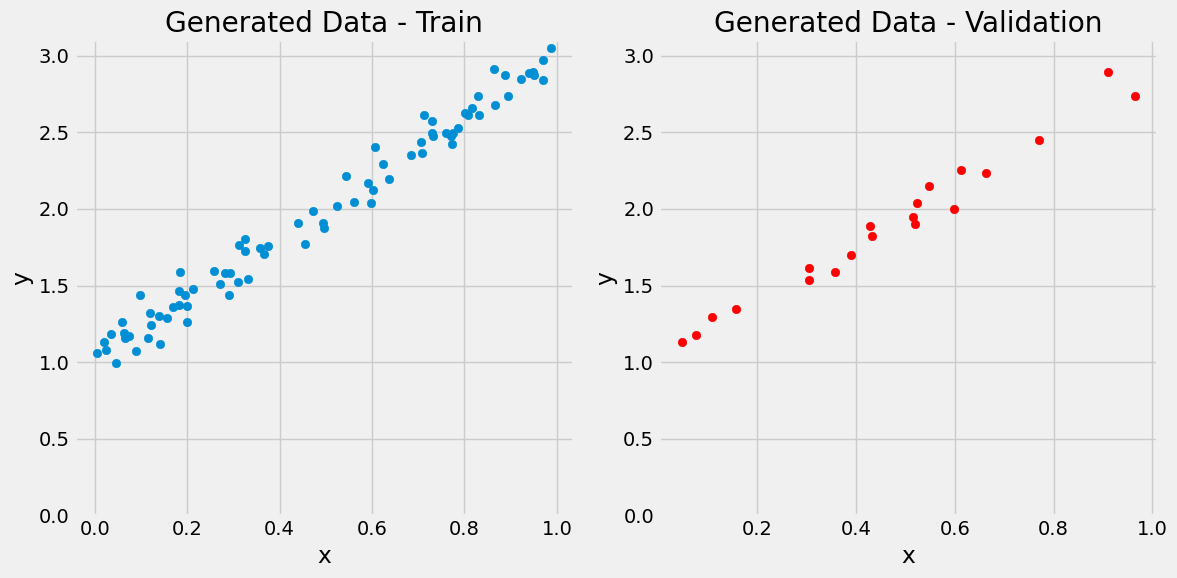

In [ ]:
figure1(x_train, y_train, x_val, y_val)

## 3. Step 0: Random Initialization

In [ ]:
# Step 0 - Initializes parameters "b" and "w" randomly
# y = b+wx
np.random.seed(42)
b = np.random.randn(1)
w = np.random.randn(1)

print(b, w)

[0.49671415] [-0.1382643]


## Step 1: Compute Model's Predictions

In [ ]:
# Step 1 - Computes our model's predicted output - forward pass
yhat = b + w * x_train

In [ ]:
for yt, yh in zip(y_train, yhat):
    print(f"y_true = {yt[0]:.4f} | y_pred = {yh[0]:.4f}")

y_true = 2.4745 | y_pred = 0.3901
y_true = 1.1928 | y_pred = 0.4879
y_true = 2.9128 | y_pred = 0.3774
y_true = 1.0785 | y_pred = 0.4932
y_true = 2.4732 | y_pred = 0.3955
y_true = 1.1713 | y_pred = 0.4865
y_true = 1.2654 | y_pred = 0.4692
y_true = 1.5245 | y_pred = 0.4537
y_true = 1.9857 | y_pred = 0.4314
y_true = 2.8401 | y_pred = 0.3627
y_true = 1.2406 | y_pred = 0.4798
y_true = 2.4936 | y_pred = 0.3895
y_true = 2.6229 | y_pred = 0.3858
y_true = 2.5751 | y_pred = 0.3958
y_true = 1.4417 | y_pred = 0.4832
y_true = 1.5888 | y_pred = 0.4712
y_true = 1.2901 | y_pred = 0.4751
y_true = 1.1327 | y_pred = 0.4939
y_true = 3.0520 | y_pred = 0.3603
y_true = 2.2940 | y_pred = 0.4105
y_true = 2.3660 | y_pred = 0.3988
y_true = 2.0407 | y_pred = 0.4140
y_true = 2.8506 | y_pred = 0.3693
y_true = 2.1930 | y_pred = 0.4086
y_true = 1.5846 | y_pred = 0.4579
y_true = 1.5967 | y_pred = 0.4609
y_true = 1.3214 | y_pred = 0.4802
y_true = 2.4927 | y_pred = 0.3959
y_true = 2.8903 | y_pred = 0.3655
y_true = 2.403

(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

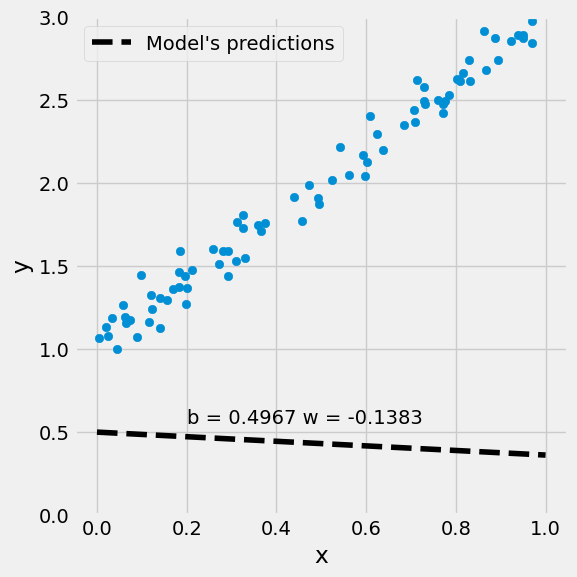

In [ ]:
figure2(x_train, y_train, b, w)

## Compute Loss
$$
\Large \text{error}_i = \hat{y_i} - y_i
$$

(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

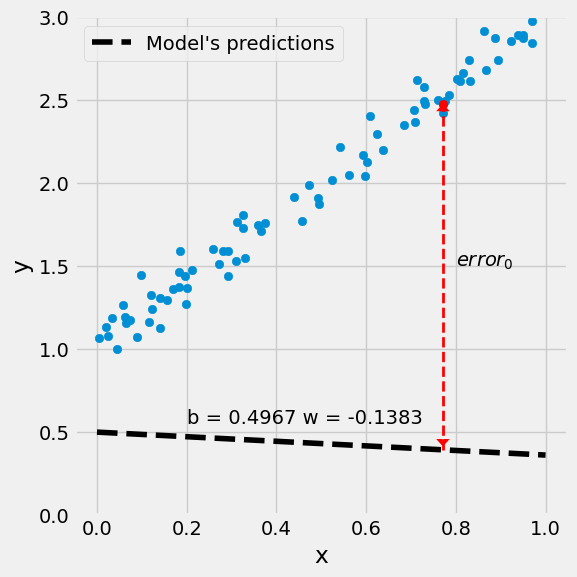

In [ ]:
figure3(x_train, y_train, b, w)

In [ ]:
# First data point
x0, y0 = x_train[0][0], y_train[0][0]
print(x0,y0)

0.7712703466859457 2.474538221214042


In [ ]:
# Select the first data point
x0 = x_train[0][0]
y0 = y_train[0][0]

# Model prediction at x0
y_pred0 = b[0] + w[0] * x0

# Print the pairs
print(f"(x0, y0)     = ({x0:.4f}, {y0:.4f})")
print(f"(x0, y_pred) = ({x0:.4f}, {y_pred0:.4f})")
# Error (prediction - true value)
error0 = y_pred0 - y0

print(f"y_pred - y0 = {error0:.4f}")


(x0, y0)     = (0.7713, 2.4745)
(x0, y_pred) = (0.7713, 0.3901)
y_pred - y0 = -2.0845


### Mean squared error(MSE)
$$
\Large
\begin{aligned}
\text{MSE} &= \frac{1}{n} \sum_{i=1}^n{\text{error}_i}^2
\\
&= \frac{1}{n} \sum_{i=1}^n{(\hat{y_i} - y_i)}^2
\\
&= \frac{1}{n} \sum_{i=1}^n{(b + w x_i - y_i)}^2
\end{aligned}
$$

In [ ]:
# Step 2 - Computing MSE loss
# We are using ALL data points, so this is BATCH gradient
# descent. How wrong is our model? That's the error!
error = (yhat - y_train)

# It is a regression, so it computes mean squared error (MSE)
loss = (error ** 2).mean()
print(loss)

2.7421577700550976


## Loss Surface
Tính toán và trực quan hóa bề mặt hàm mất mát (loss surface) của mô hình hồi quy tuyến tính theo hai tham số (w) và (b).


In [ ]:
# Reminder:
# true_b = 1
# true_w = 2
# Tạo dải giá trị cho 𝑏 và 𝑤
# we have to split the ranges in 100 evenly spaced intervals each
b_range = np.linspace(true_b - 3, true_b + 3, 101)
w_range = np.linspace(true_w - 3, true_w + 3, 101)
# Tạo lưới tham số (parameter grid)
# meshgrid is a handy function that generates a grid of b and w
# values for all combinations
bs, ws = np.meshgrid(b_range, w_range)
bs.shape, ws.shape
# 101×101=10,201 cặp (w,b), 80 mẫu => mỗi mẫu có (101, 101) giá trị dự đoán

((101, 101), (101, 101))

In [ ]:
# Chuẩn bị dữ liệu huấn luyện, tính giá trị dự đoán mẫu cho từng cặp w,b
sample_x = x_train[0]
sample_yhat = bs + ws * sample_x
sample_yhat.shape

(101, 101)

In [ ]:
# Tính toàn bộ dự đoán cho mọi mẫu
all_predictions = np.apply_along_axis(
    func1d=lambda x: bs + ws * x,
    axis=1,
    arr=x_train
)
all_predictions.shape

(80, 101, 101)

In [ ]:
# Nhãn thật
# Định dạng lại nhãn để broadcast với dự đoán (80, 1) → (80, 1, 1),
all_labels = y_train.reshape(-1, 1, 1)
all_labels.shape


(80, 1, 1)

In [ ]:
# Tính sai số (errors) dự đoán
all_errors = (all_predictions - all_labels)
all_errors.shape

(80, 101, 101)

In [ ]:
# Tính loss (MSE)
# Lấy trung bình theo axis=0 (theo mẫu)
all_losses = (all_errors ** 2).mean(axis=0)
all_losses.shape

(101, 101)

(<Figure size 1200x600 with 2 Axes>,
 (<Axes3D: title={'center': 'Loss Surface'}, xlabel='b', ylabel='w'>,
  <Axes: title={'center': 'Loss Surface'}, xlabel='b', ylabel='w'>))

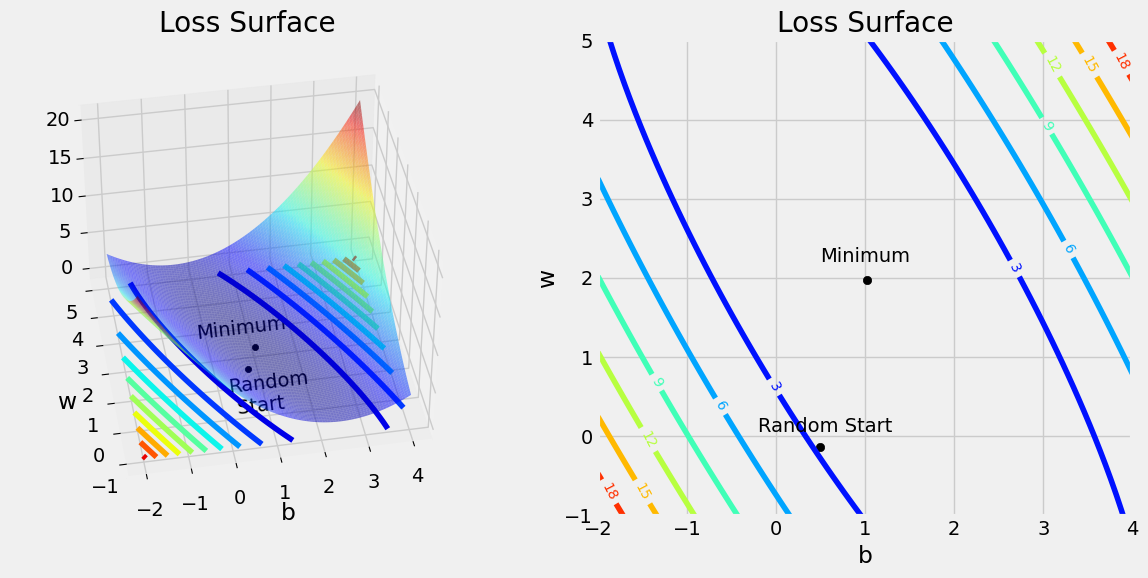

In [ ]:
figure4(x_train, y_train, b, w, bs, ws, all_losses)

## Cross Sections
Lát cắt của Loss Surface: Giữ một tham số cố định. Cho tham số còn lại thay đổi

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Loss Surface'}, xlabel='b', ylabel='w'>,
        <Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='Loss'>],
       dtype=object))

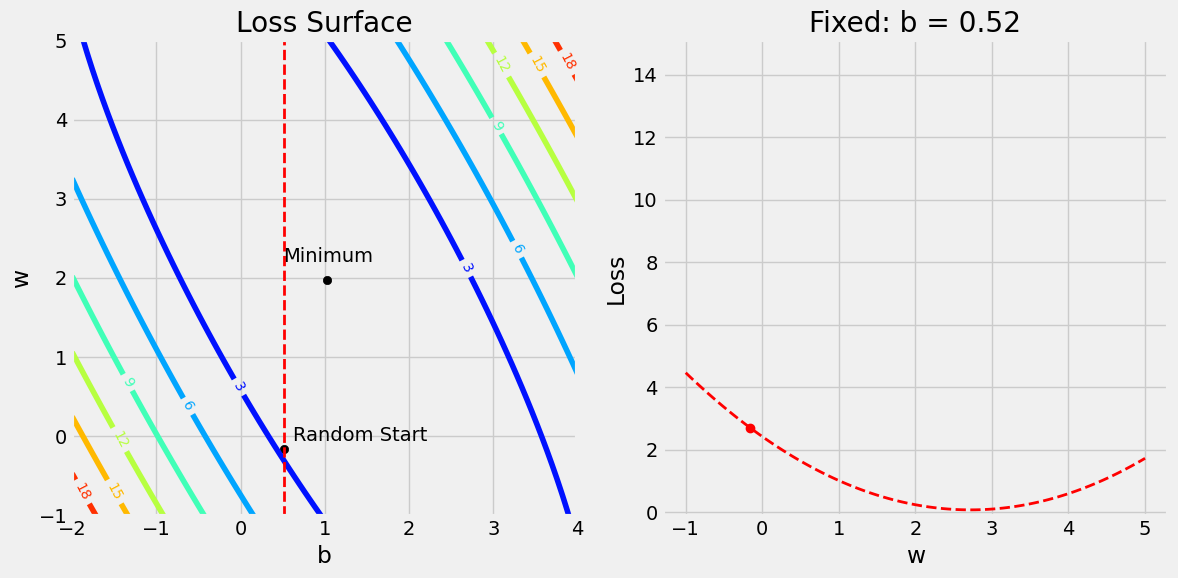

In [ ]:
figure5(x_train, y_train, b, w, bs, ws, all_losses)
# Khi giữ 𝑏 cố định, loss là hàm lồi theo w

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Loss Surface'}, xlabel='b', ylabel='w'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b', ylabel='Loss'>],
       dtype=object))

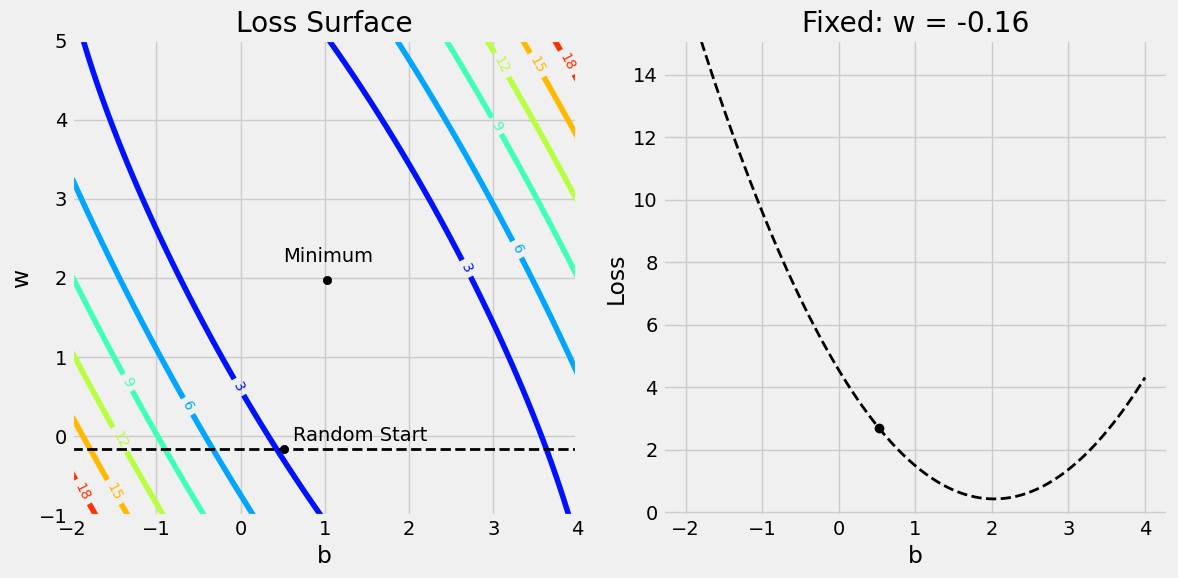

In [ ]:
figure6(x_train, y_train, b, w, bs, ws, all_losses)
# Khi giữ 𝑤 cố định, loss cũng lồi theo 𝑏


## Step 3: Compute the Gradients
$$
\Large
\begin{aligned}
\frac{\partial{\text{MSE}}}{\partial{b}} = \frac{\partial{\text{MSE}}}{\partial{\hat{y_i}}} \frac{\partial{\hat{y_i}}}{\partial{b}} &= \frac{1}{n} \sum_{i=1}^n{2(b + w x_i - y_i)}
\\
&= 2 \frac{1}{n} \sum_{i=1}^n{(\hat{y_i} - y_i)}
\\
\frac{\partial{\text{MSE}}}{\partial{w}} = \frac{\partial{\text{MSE}}}{\partial{\hat{y_i}}} \frac{\partial{\hat{y_i}}}{\partial{w}} &= \frac{1}{n} \sum_{i=1}^n{2(b + w x_i - y_i) x_i}
\\
&= 2 \frac{1}{n} \sum_{i=1}^n{x_i (\hat{y_i} - y_i)}
\end{aligned}
$$

In [ ]:
# Step 3 - Computes gradients for both "b" and "w" parameters
b_grad = 2 * error.mean()
w_grad = 2 * (x_train * error).mean()
print(b_grad, w_grad)

-3.044811379650508 -1.8337537171510832


## Visualizing the Gradients

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='MSE (loss)'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b'>],
       dtype=object))

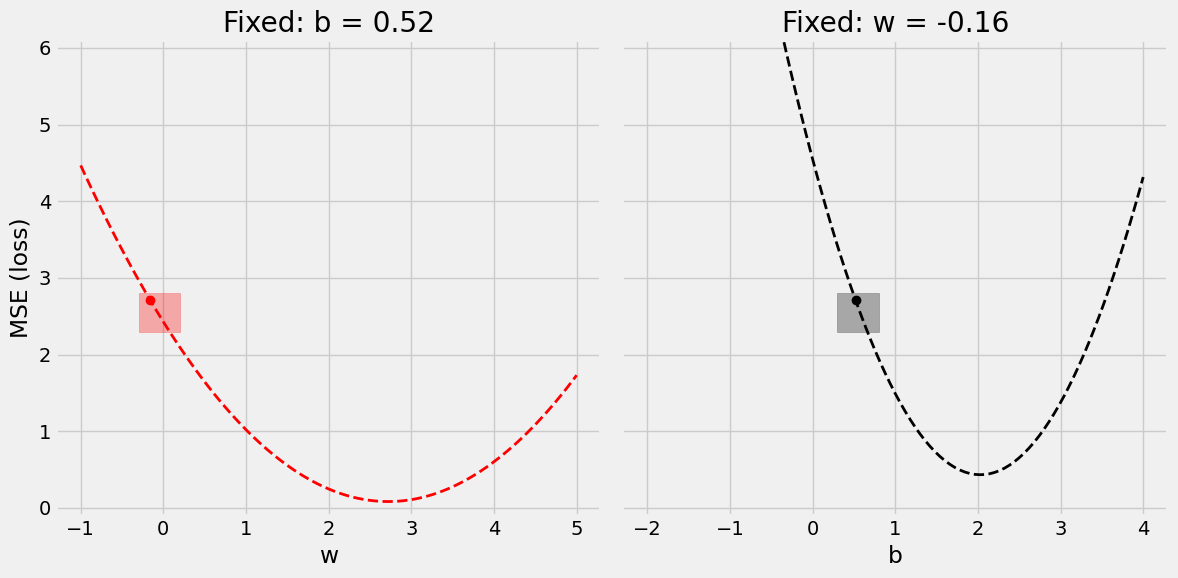

In [ ]:
figure7(b, w, bs, ws, all_losses)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='MSE (loss)'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b'>],
       dtype=object))

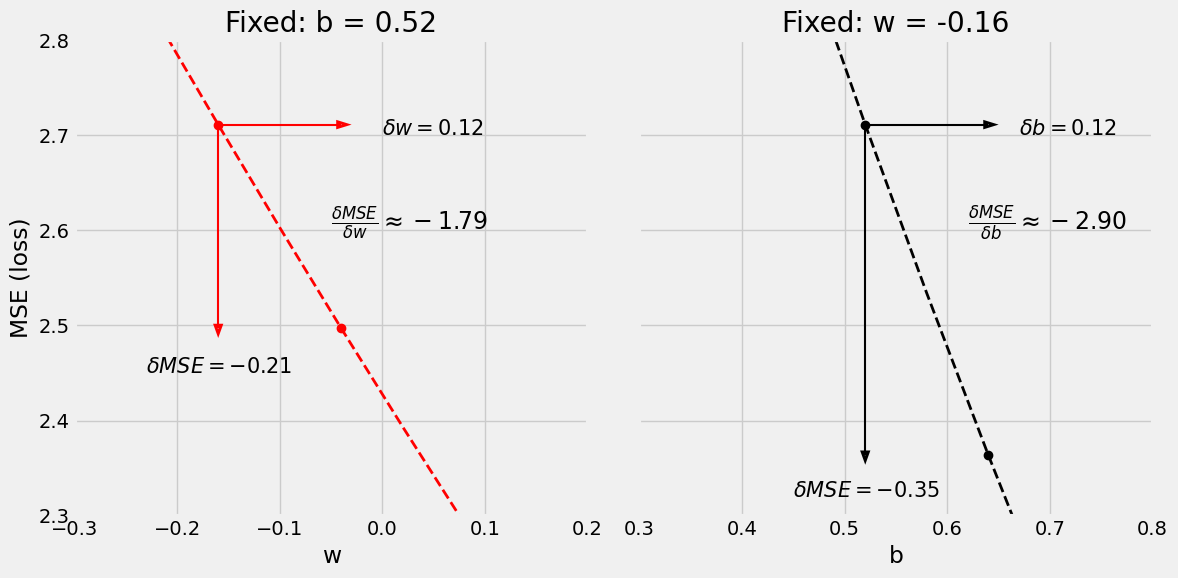

In [ ]:
figure8(b, w, bs, ws, all_losses)

$$
\Large
\begin{aligned}
b &= b - \eta \frac{\partial{\text{MSE}}}{\partial{b}}
\\
w &= w - \eta \frac{\partial{\text{MSE}}}{\partial{w}}
\end{aligned}
$$

In [ ]:
# Sets learning rate - this is "eta" ~ the "n" like Greek letter
lr = 0.1
print(b, w)

# Step 4 - Updates parameters using gradients and the
# learning rate
b = b - lr * b_grad
w = w - lr * w_grad

print(b, w)

[0.49671415] [-0.1382643]
[0.80119529] [0.04511107]


(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

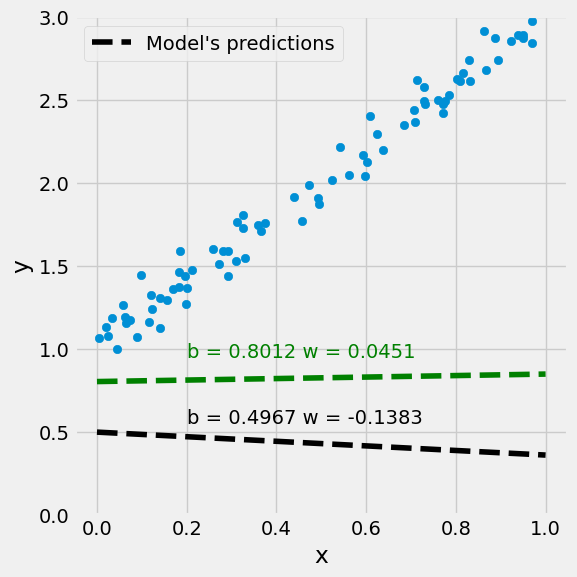

In [ ]:
figure9(x_train, y_train, b, w)

## Bài tập:
### - Hãy hoàn thiện tiếp qua trình tính toán và cập nhật parameter b, w để làm cho mô hình hội tụ dần từ khi khởi tạo ban đầu cho đến khi có kết quả như hình dưới.
### - Yêu cầu cứ mỗi bước cập nhật giá trị cho b, w thì vẽ hình tương ứng cho đến khi fix với dữ liệu.

Initial b: 0.4967, w: -0.1383
Epoch   0 | Loss: 2.7422 | b: 0.8012 | w: 0.0451


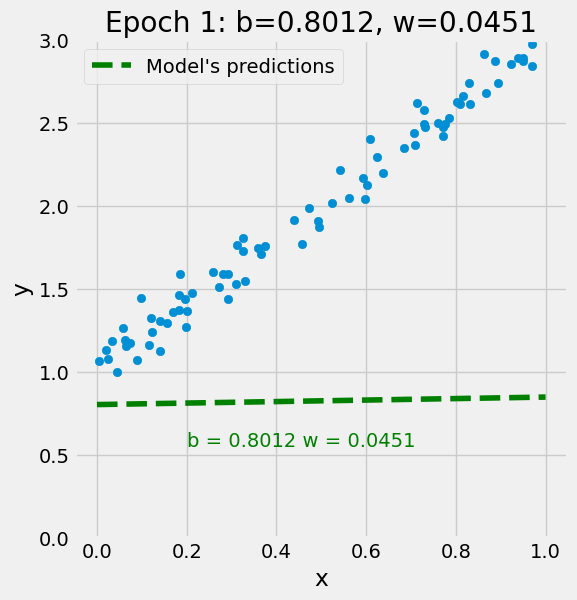

Epoch  10 | Loss: 0.1657 | b: 1.5984 | w: 0.7082


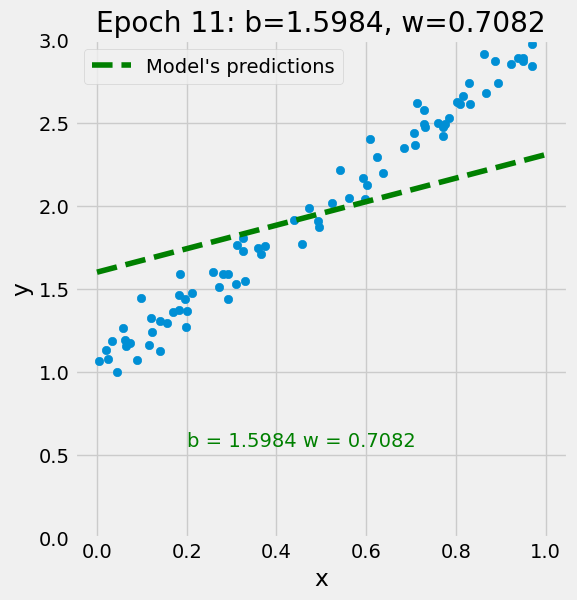

Epoch  20 | Loss: 0.1181 | b: 1.5614 | w: 0.9087


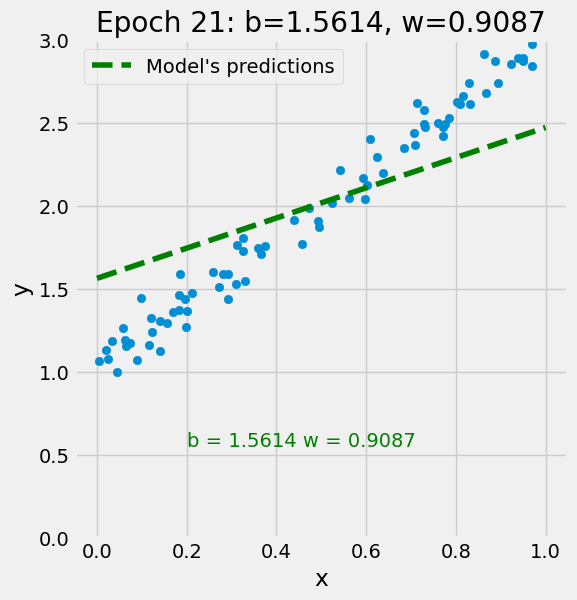

Epoch  30 | Loss: 0.0892 | b: 1.4880 | w: 1.0597


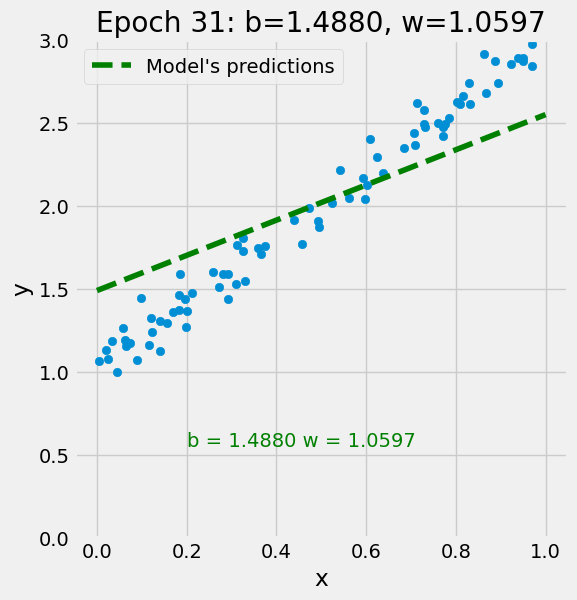

Epoch  40 | Loss: 0.0679 | b: 1.4225 | w: 1.1882


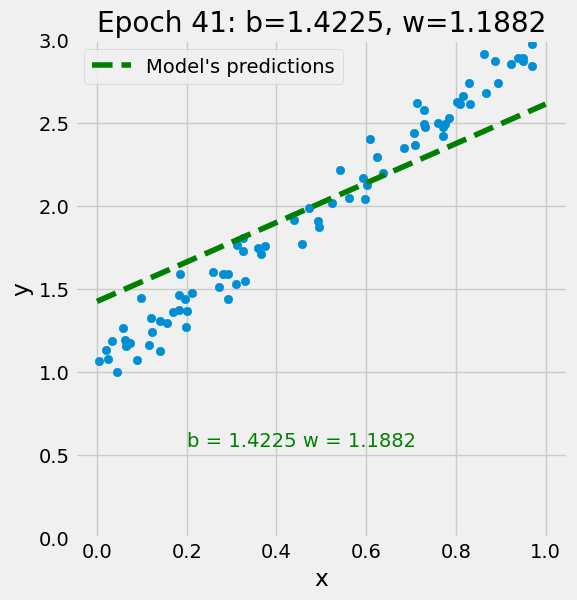

Epoch  50 | Loss: 0.0522 | b: 1.3662 | w: 1.2985


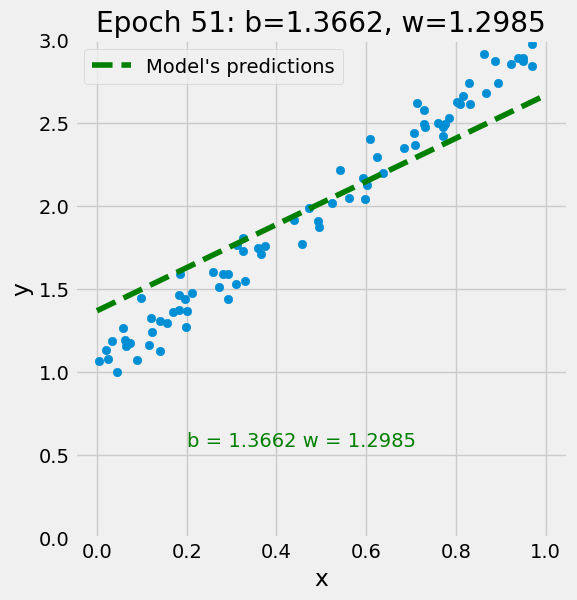

Epoch  60 | Loss: 0.0406 | b: 1.3178 | w: 1.3931


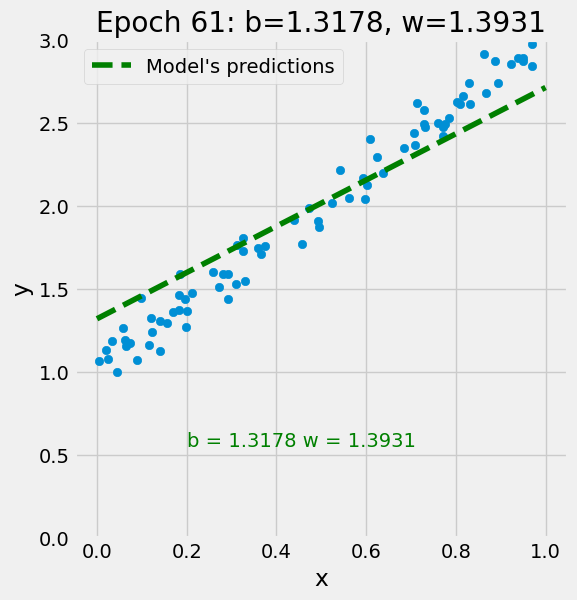

Epoch  70 | Loss: 0.0321 | b: 1.2763 | w: 1.4744


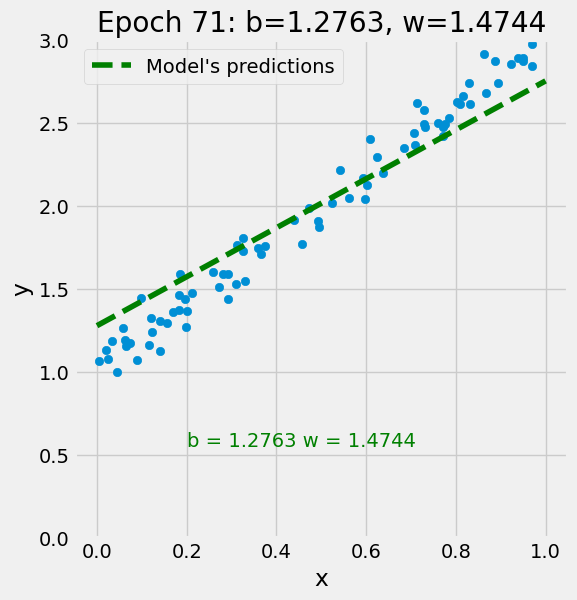

Epoch  80 | Loss: 0.0258 | b: 1.2406 | w: 1.5443


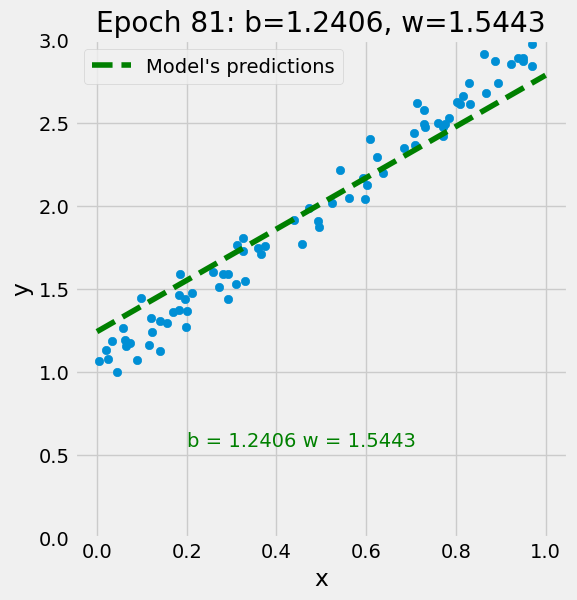

Epoch  90 | Loss: 0.0211 | b: 1.2099 | w: 1.6042


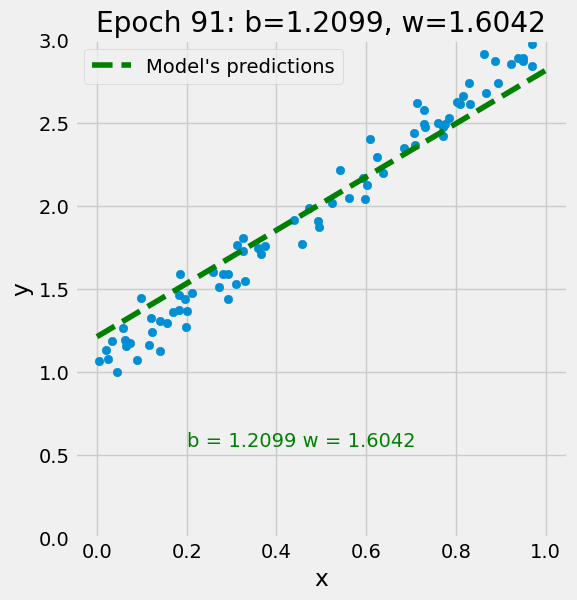

Epoch  99 | Loss: 0.0180 | b: 1.1861 | w: 1.6509


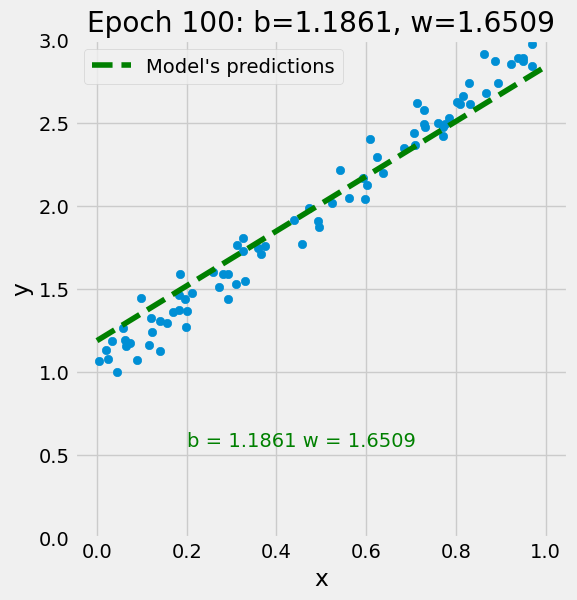


Final b: 1.1861, w: 1.6509


In [ ]:
# Re-initialize b and w for a fresh start
np.random.seed(42)
b = np.random.randn(1)
w = np.random.randn(1)

# Set learning rate
lr = 0.1

# Number of iterations
epochs = 100

print(f"Initial b: {b[0]:.4f}, w: {w[0]:.4f}")

for epoch in range(epochs):
    # Step 1 - Computes our model's predicted output - forward pass
    yhat = b + w * x_train

    # Step 2 - Computing MSE loss
    error = (yhat - y_train)
    loss = (error ** 2).mean()

    # Step 3 - Computes gradients for both "b" and "w" parameters
    b_grad = 2 * error.mean()
    w_grad = 2 * (x_train * error).mean()

    # Step 4 - Updates parameters using gradients and the learning rate
    b = b - lr * b_grad
    w = w - lr * w_grad

    if epoch % 10 == 0 or epoch == epochs -1:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | b: {b[0]:.4f} | w: {w[0]:.4f}")
        # Visualize the current model
        figure2(x_train, y_train, b, w, color='g')
        plt.title(f'Epoch {epoch+1}: b={b[0]:.4f}, w={w[0]:.4f}')
        plt.show()

print(f"\nFinal b: {b[0]:.4f}, w: {w[0]:.4f}")

## Learning Rate

In [ ]:
### Learning Rate
manual_grad_b = -2.90
manual_grad_w = -1.79

np.random.seed(42)
b_initial = np.random.randn(1)
w_initial = np.random.randn(1)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='MSE (loss)'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b'>],
       dtype=object))

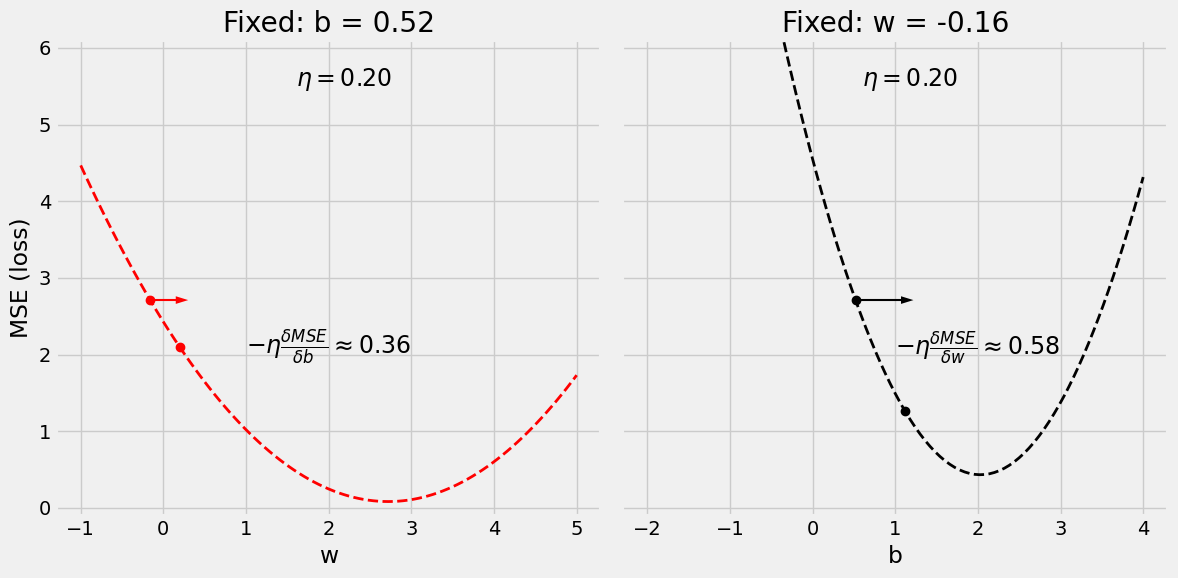

In [ ]:
#### Low Learning Rate
# Learning rate - greek letter "eta" that looks like an "n"
lr = .2
# b = b_initial - lr * manual_grad_b
# w = w_initial - lr * manual_grad_w

figure10(b_initial, w_initial, bs, ws, all_losses, manual_grad_b, manual_grad_w, lr)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='MSE (loss)'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b'>],
       dtype=object))

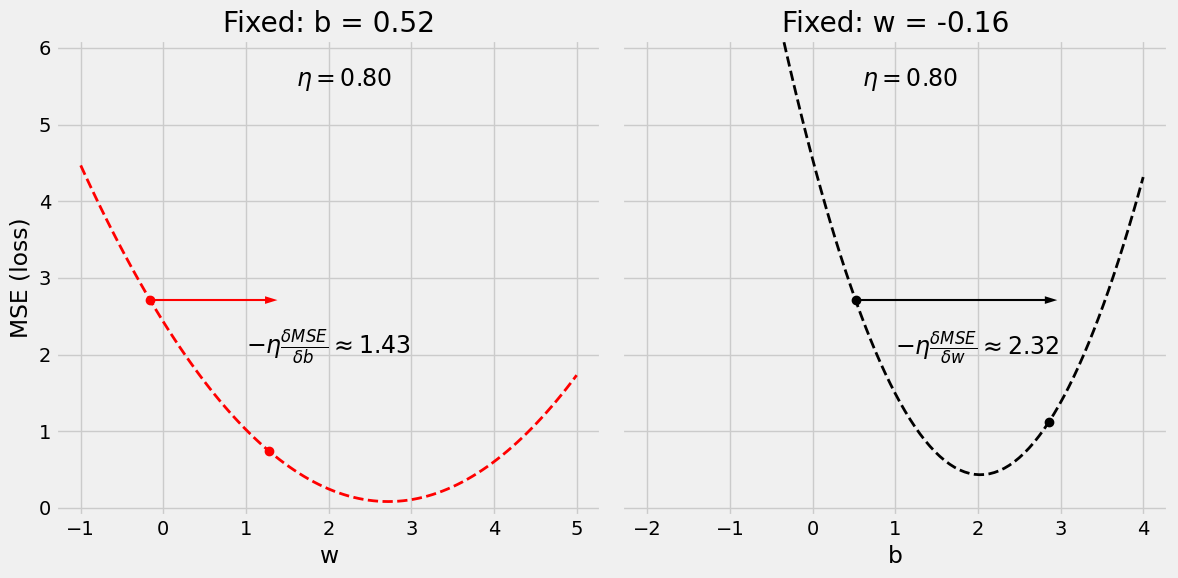

In [ ]:
#High Learning Rate
#Learning rate - greek letter "eta" that looks like an "n"
lr = .8

figure10(b_initial, w_initial, bs, ws, all_losses, manual_grad_b, manual_grad_w, lr)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Fixed: b = 0.52'}, xlabel='w', ylabel='MSE (loss)'>,
        <Axes: title={'center': 'Fixed: w = -0.16'}, xlabel='b'>],
       dtype=object))

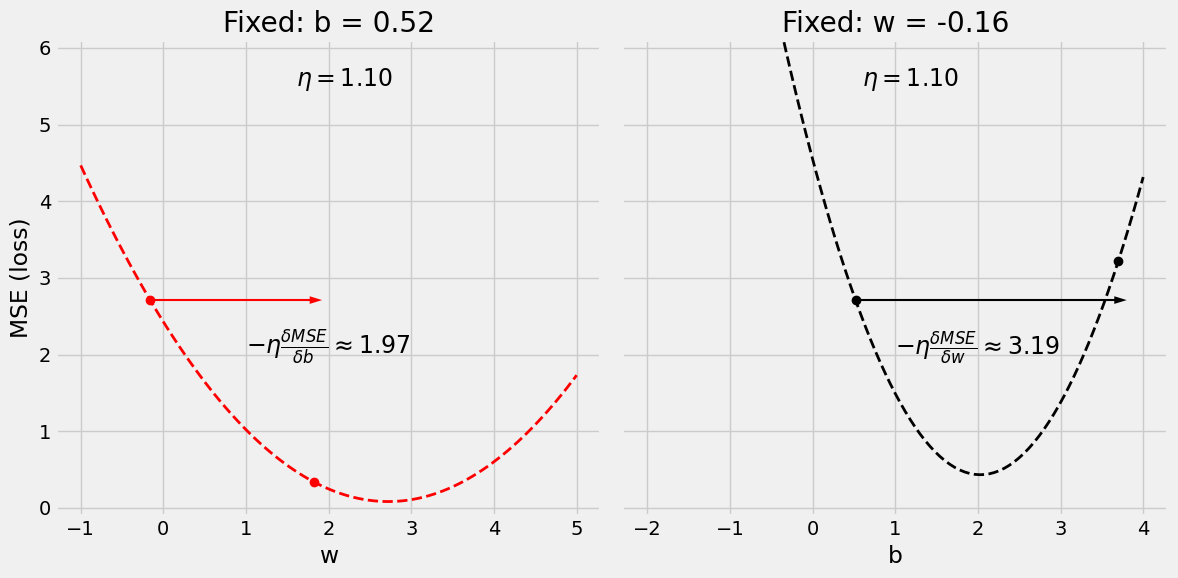

In [ ]:
# Very High Learning Rate
# Learning rate - greek letter "eta" that looks like an "n"
lr = 1.1

figure10(b_initial, w_initial, bs, ws, all_losses, manual_grad_b, manual_grad_w, lr)